# 04. Modelo de Imagenes

In [1]:
import sys
sys.path.append("..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from src.image_features import ImageFeatureExtractor, PHOTOS_DIR


## 1. Cargar metadata de fotos

Fotos: 60199 | Restaurantes con fotos: 3824
Promedio fotos/restaurante: 15.7


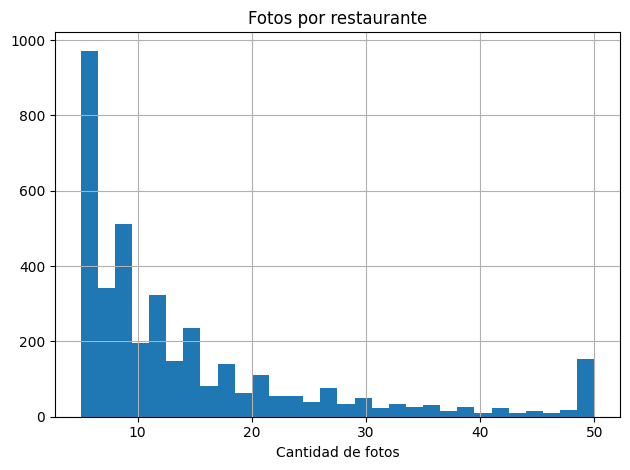

In [2]:
photos = pd.read_csv('../data/processed/photos.csv')
restaurants = pd.read_csv('../data/processed/restaurants.csv')

photos_per_rest = photos.groupby('business_id').size()
print(f'Fotos: {len(photos)} | Restaurantes con fotos: {photos["business_id"].nunique()}')
print(f'Promedio fotos/restaurante: {photos_per_rest.mean():.1f}')
photos_per_rest.clip(upper=50).hist(bins=30)
plt.title('Fotos por restaurante')
plt.xlabel('Cantidad de fotos')
plt.tight_layout()

## 2. Visualizar algunas fotos de muestra

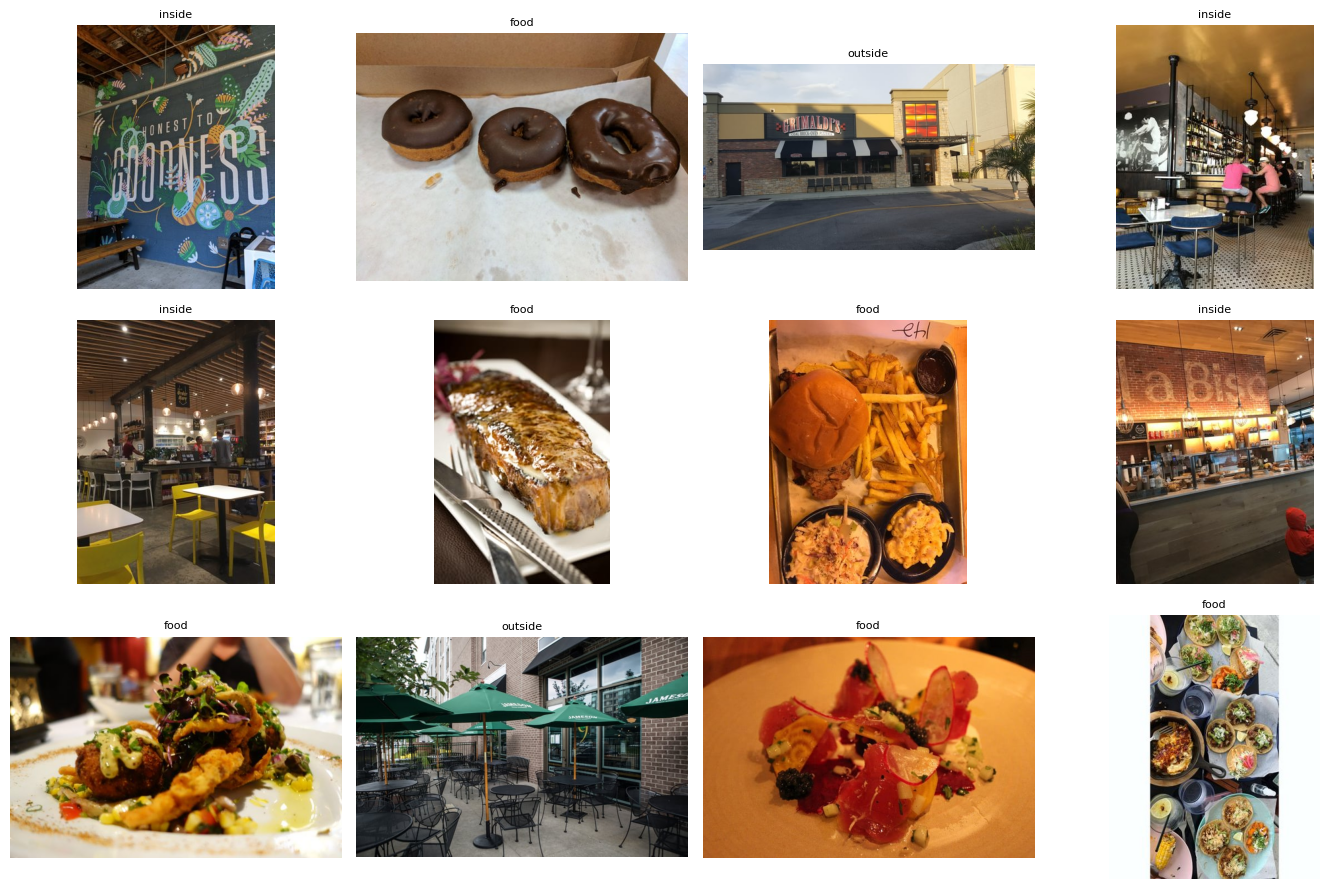

In [3]:
sample_photos = photos.sample(min(12, len(photos)), random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, (_, row) in zip(axes.flat, sample_photos.iterrows()):
    path = os.path.join(PHOTOS_DIR, f"{row['photo_id']}.jpg")
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(row.get('label', ''), fontsize=8)
    ax.axis('off')
plt.tight_layout()

## 3. Extraer embeddings de imagenes

In [4]:
EMB_FILE = 'image_embeddings.npz'
EMB_PATH = f'../data/embeddings/{EMB_FILE}'

if os.path.exists(EMB_PATH):
    print('Loading cached image embeddings...')
    image_embeddings = ImageFeatureExtractor.load(EMB_FILE)
else:
    extractor = ImageFeatureExtractor()
    image_embeddings = extractor.extract(photos)
    extractor.save(image_embeddings, EMB_FILE)

print(f'Image embeddings: {len(image_embeddings)} restaurantes, dim={next(iter(image_embeddings.values())).shape[0]}')

Loading cached image embeddings...
Image embeddings: 3824 restaurantes, dim=2048


## 4. Restaurantes más similares visualmente

In [5]:
ids = list(image_embeddings.keys())
matrix_arr = np.stack([image_embeddings[i] for i in ids])
id_to_idx = {bid: i for i, bid in enumerate(ids)}

sample_id = ids[0]
sample_name = restaurants[restaurants["business_id"] == sample_id]["name"].values
print(f"Query: {sample_name}")

query = matrix_arr[id_to_idx[sample_id]].reshape(1, -1)
sims = cosine_similarity(query, matrix_arr)[0]
sims[id_to_idx[sample_id]] = -1
for i in np.argsort(sims)[::-1][:5]:
    name = restaurants[restaurants["business_id"] == ids[i]]["name"].values
    print(f"  {name} — visual similarity: {sims[i]:.3f}")


Query: ['HopCat - Broad Ripple']
  ['National Mechanics'] — visual similarity: 0.972
  ["Manning's Sports Bar and Grill"] — visual similarity: 0.970
  ["Legacy Kitchen's Craft Tavern"] — visual similarity: 0.970
  ['Napoleon House'] — visual similarity: 0.969
  ['Crescent City Brewhouse'] — visual similarity: 0.969
